In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st

df = pd.read_csv('/datasets/games.csv')
df.columns = df.columns.str.lower()


df.info()
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
r

<ol>
    <li>
        <p><b>user_score</b>: deberia ser <i>float</i> pero a causa de valores TBD es object</p>
    </li>
    <li>
        <p><b>name y genre</b>: tienen valores vacios los cuales deberian eliminarse porque ni podemos clasificarlos para este análisis</p>
    </li>
    <li>
        <p><b>rating</b>: tienen valores vacios estos no deben eliminarse porque son demasiados, en su lugar hay que llenar estos valores con 'Unknown'</p>
    </li>
    <li>
        <p><b>user_score</b>: En este caso los valores nulos deben reemplazarse con NaN y convertiese a float</p>
    </li>
    <li>
        <p><b>year_of_release</b>: tiene valores vacios, en este caso podemos rellenarlos con la media</p>
    </li>
    <li>
        <p><b>critic_score</b>: Casi la mitad de los valores estan vacios, asi se necesita un nuevo campo que indique que si tiene un valor y despues asignarle -1 a los vacios para que pueda contener un valor entero</p>
    </li>
</ol>

In [2]:
df = df.dropna(subset=['name', 'genre'])
df['rating'] = df['rating'].fillna('Unknown')
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

median_year = df['year_of_release'].median()
df['year_of_release'] = df['year_of_release'].fillna(median_year)
df['year_of_release'] = df['year_of_release'].astype(int)

df['has_critic_score'] = df['critic_score'].notnull().astype(int)
df['critic_score'] = df['critic_score'].fillna(-1)

df['total_sales'] = df[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)



df.info()
print()
print(df.isnull().sum())
print()
print(df['user_score'].dtype)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16713 entries, 0 to 16714
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              16713 non-null  object 
 1   platform          16713 non-null  object 
 2   year_of_release   16713 non-null  int64  
 3   genre             16713 non-null  object 
 4   na_sales          16713 non-null  float64
 5   eu_sales          16713 non-null  float64
 6   jp_sales          16713 non-null  float64
 7   other_sales       16713 non-null  float64
 8   critic_score      16713 non-null  float64
 9   user_score        7590 non-null   float64
 10  rating            16713 non-null  object 
 11  has_critic_score  16713 non-null  int64  
 12  total_sales       16713 non-null  float64
dtypes: float64(7), int64(2), object(4)
memory usage: 1.8+ MB

name                   0
platform               0
year_of_release        0
genre                  0
na_sales               

In [3]:
games_per_year = df.groupby('year_of_release')['name'].count()

# Ver los años con más lanzamientos
print(games_per_year.sort_index(ascending=False))

year_of_release
2016     502
2015     606
2014     581
2013     544
2012     653
2011    1136
2010    1255
2009    1426
2008    1427
2007    1466
2006    1006
2005     939
2004     762
2003     775
2002     829
2001     482
2000     350
1999     338
1998     379
1997     289
1996     263
1995     219
1994     121
1993      60
1992      43
1991      41
1990      16
1989      17
1988      15
1987      16
1986      21
1985      14
1984      14
1983      17
1982      36
1981      46
1980       9
Name: name, dtype: int64


<ol>
    <li>
        La Era "Pre-Internet" (1980 - 1995)
        <ul>
            <li>Volumen muy bajo (pocos juegos por año)</li>
            <li>Los datos son significativos historicamente, pero no estadísticamente</li>
            <li>Hay muchos valores faltantes en critic_score y user_score porque las revistas especializadas y los agregadores online no existían o no cubrían todo</li>
        </ul>
    </li>
    <li>
        La "Guerra" de las Consolas (1995 - 2008)
        <ul>
            <li>Alto volumen, especialmente con PS1, PS2 y Wii</li>
            <li>Aquí es donde la mayoría de los juegos tienen rating y puntuaciones. Los picos suelen estar alrededor de 2008-2009, con más de 1,400 lanzamientos anuales</li>
        </ul>
    </li>
    <li>
        La era digital y movil
        <ul>
            <li>
                Caída en el volumen de juegos físicos registrados
            </li>
            <li>
                El número de juegos baja drásticamente después de 2012, no es porque se hagan menos juegos, sino porque el dataset se enfoca en ventas físicas, pero muchos juegos se han comenzado a distribuir digitalmente o entran en la categoría d eindies que podrian no estar en este dataset
            </li>
        </ul>
    </li>
</ol>

In [4]:
# Las reinas en ventas
platform_sales = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
top_platforms = platform_sales.head(5).index

print(f"Top 5 plataformas: {list(top_platforms)}")

Top 5 plataformas: ['PS2', 'X360', 'PS3', 'Wii', 'DS']


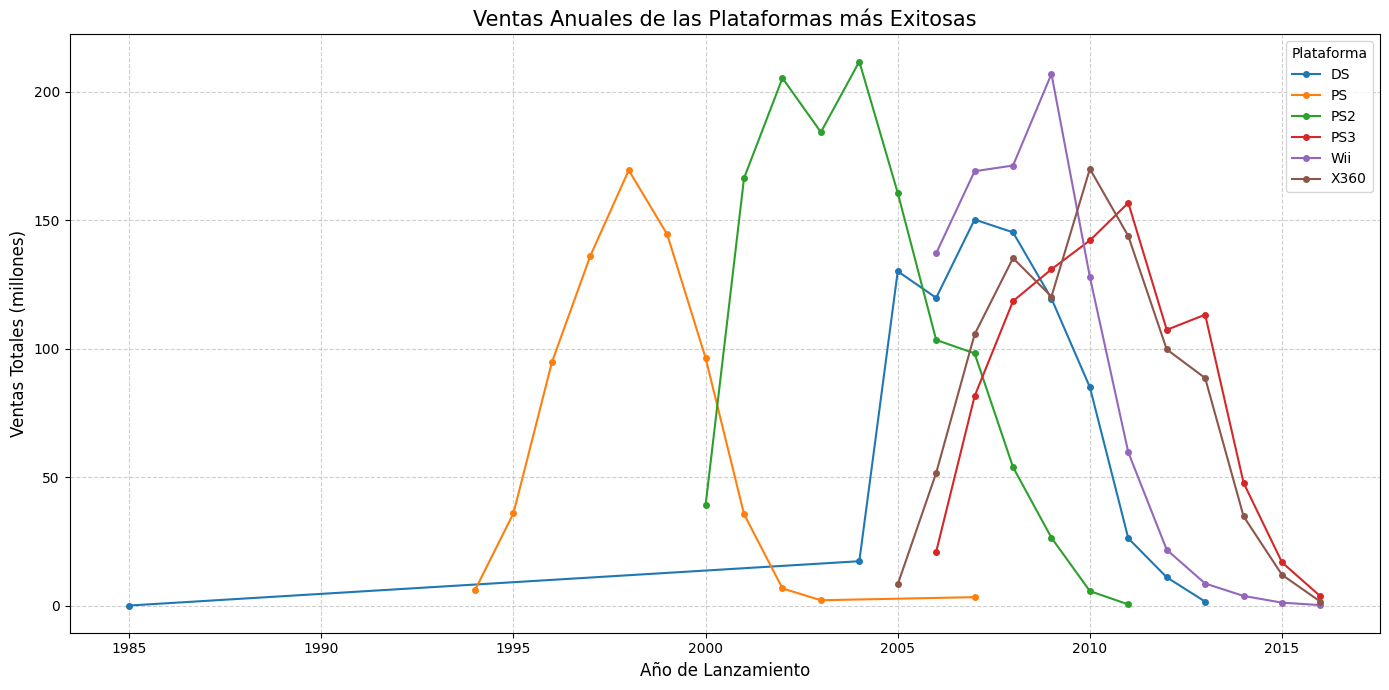

In [5]:

top_platforms = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(6).index


platform_data = df[df['platform'].isin(top_platforms)].pivot_table(
    index='year_of_release', 
    columns='platform', 
    values='total_sales', 
    aggfunc='sum'
)


plt.figure(figsize=(14, 7))

for platform in platform_data.columns:
    data_to_plot = platform_data[platform].dropna()
    plt.plot(data_to_plot.index, data_to_plot.values, label=platform, marker='o', markersize=4)

plt.title('Ventas Anuales de las Plataformas más Exitosas', fontsize=15)
plt.xlabel('Año de Lanzamiento', fontsize=12)
plt.ylabel('Ventas Totales (millones)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Plataforma')

plt.tight_layout()
plt.show()

<ul>
    <li>
        <p><b>Las reinas de las ventas de todos los tiempos</b>: PS2, X360, PS3, Wii, DS en ese orden</p>
    </li>
    <li>
        <p>
            <b>Aparición y Auge</b>:Una plataforma nueva tarda generalmente entre 2 y 3 años en alcanzar su punto máximo de ventas. Es el tiempo que necesitan los desarrolladores para entender el hardware y sacar los títulos AAA
        </p>
    </li>
    <li>
        <p>
            <b>Duración en el mercado</b>: Las plataformas antiguas suelen tardar unos 10 años en desaparecer por completo desde su lanzamiento. Por ejemplo, la PS2 tuvo un dominio absoluto, pero tras el lanzamiento de la PS3, sus ventas tardaron unos 5 años en volverse irrelevantes.
        </p>
    </li>
    <li>
        <p>
            <b>Desaparición</b>: En los datos más recientes verás que la DS, la PS2 y la Wii ya no tienen ventas, a pesar de haber tenido los picos más altos de la historia. Han sido completamente reemplazadas por sus sucesoras.
        </p>
    </li>
    <li>
        <p>
            <b>Obervación</b>: Esto solo llega a mediados de 2015, por lo tanto necesitamos ver el compórtamiento de las consolas mas recientes para tenedr un panorama mas completo
        </p>
    </li>
</ul>

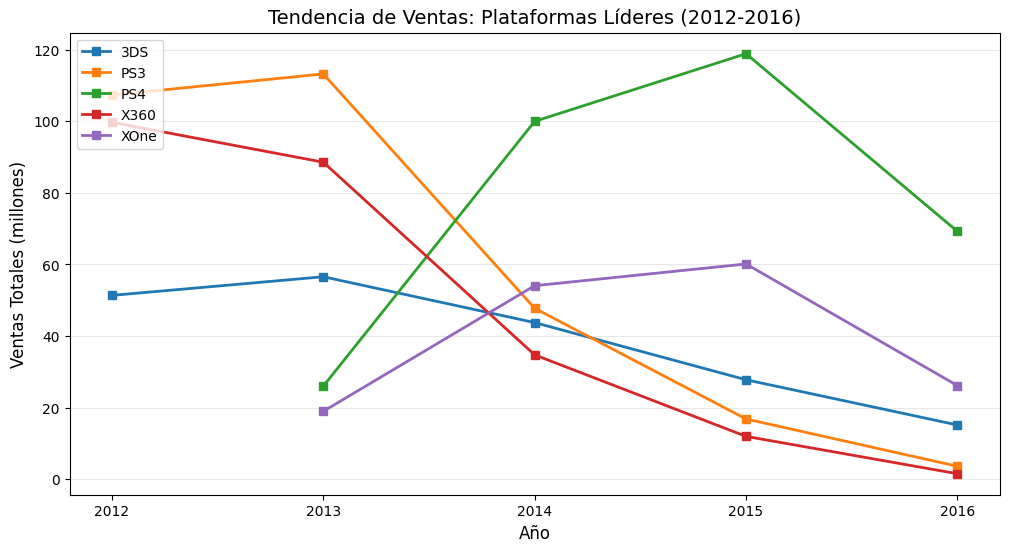

In [6]:
recent_years_df = df[df['year_of_release'] >= 2012]

top_recent = recent_years_df.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(5).index

recent_pivot = recent_years_df[recent_years_df['platform'].isin(top_recent)].pivot_table(
    index='year_of_release', 
    columns='platform', 
    values='total_sales', 
    aggfunc='sum'
)

plt.figure(figsize=(12, 6))

for platform in recent_pivot.columns:
    data = recent_pivot[platform].dropna()
    plt.plot(data.index, data.values, label=platform, marker='s', linestyle='-', linewidth=2)

plt.title('Tendencia de Ventas: Plataformas Líderes (2012-2016)', fontsize=14)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Ventas Totales (millones)', fontsize=12)
plt.xticks(recent_pivot.index) # Asegura que solo se muestren años enteros
plt.legend(loc='upper left')
plt.grid(True, axis='y', alpha=0.3)

plt.show()

<ul>
    <li>
        <p><b>Relevo</b>: Verás cómo la PS3 y la X360 empiezan en lo alto en 2012 pero caen en picada. Al mismo tiempo, la PS4 y la XOne aparecen (probablemente en 2013) y suben rápidamente.</p>
    </li>
    <li>
        <p><b>Velocidad de aparición</b>Las nuevas plataformas alcanzan su pico en apenas 2 años. La adopción es mucho más rápida ahora que en la época de la NES o la PS1.</p>
    </li>
    <li>
        <p><b>Declive</b><b>: Las nuevas plataformas alcanzan su pico en apenas 2 años. La adopción es mucho más rápida ahora que en la época de la NES o la PS1.</p>
    </li>
    <li>
        <p>
            <b>Aparición y Auge</b>: Una consola tarda 1-2 años en ser rentable.
        </p>
    </li>
    <li>
        <p>
            <b>Duración en el mercado</b>: El ciclo completo desde el lanzamiento hasta que las ventas son irrelevantes es de unos 10 años.
        </p>
    </li>
    <li>
        <p>
            <b>Desaparición</b>: Cada 6-7 años aparece una nueva generación que "mata" a la anterior.
        </p>
    </li>
</ul>

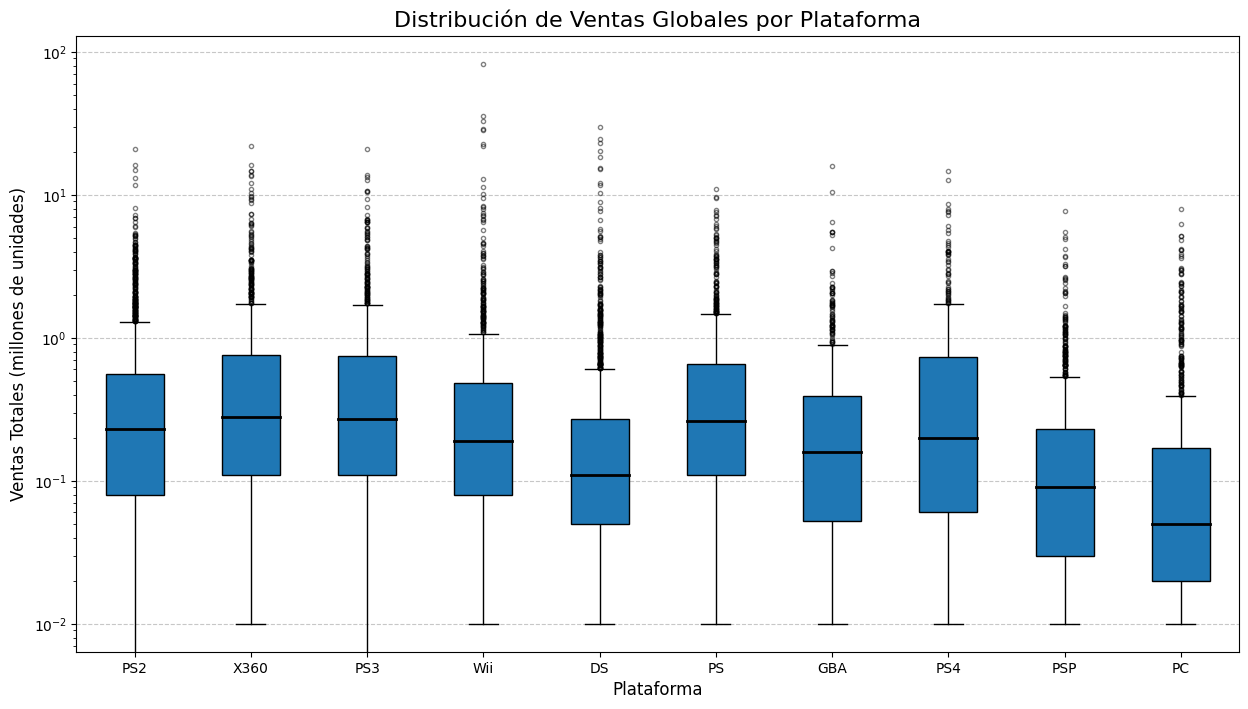

In [7]:
top_platforms = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(10).index
data_to_plot = [df[df['platform'] == p]['total_sales'] for p in top_platforms]

plt.figure(figsize=(15, 8))
plt.boxplot(data_to_plot, labels=top_platforms, patch_artist=True, 
            medianprops={'color': 'black', 'linewidth': 2},
            flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.5})

plt.title('Distribución de Ventas Globales por Plataforma', fontsize=16)
plt.ylabel('Ventas Totales (millones de unidades)', fontsize=12)
plt.xlabel('Plataforma', fontsize=12)
plt.yscale('log') # Usamos escala logarítmica porque hay juegos con ventas masivas que comprimen la caja
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

<ul>
    <li>
        <b>Significancia</b>: Sí, son muy significativas. * Las cajas (el grueso de los juegos): Si observas el cuerpo de las cajas, la mayoría de los juegos se concentran en un rango de ventas bajo (menos de 1 millón de copias)
    </li>
    <li>
        <b>Diferencia entre Tops</b>: Plataformas como PS3, X360 y PS4 tienen cajas situadas en niveles similares, lo que indica mercados comparables. Sin embargo, plataformas como DS o Wii muestran una cantidad muy alta de juegos con ventas muy bajas, compensadas por unos pocos éxitos astronómicos.
    </li>
    <li>
        <b>Mediana baja</b>: La línea dentro de la caja (mediana) suele estar bastante abajo en todas las plataformas. Esto significa que el "juego típico" no es un superventas.
    </li>
    <li>
        <b>Promedio inflado</b>: Las ventas promedio suelen ser mucho más altas que la mediana debido a los valores atípicos (outliers). Un solo juego como Wii Sports o Grand Theft Auto V empuja el promedio hacia arriba, aunque la mayoría de los juegos de esa misma consola vendan poco.
    </li>
    <li>
        <b>Super éxitos</b>:Los puntos que flotan muy por encima de las cajas representan los blockbusters.<br/>
        Plataformas como la Wii tienen outliers extremadamente alejados del resto, lo que indica que su éxito total dependió de unos pocos títulos muy populares (títulos de Nintendo).<br/>
        En plataformas como PS3 o X360, los outliers están algo más distribuidos, sugiriendo un mercado de juegos de terceros más robusto.
    </li>
</ul>

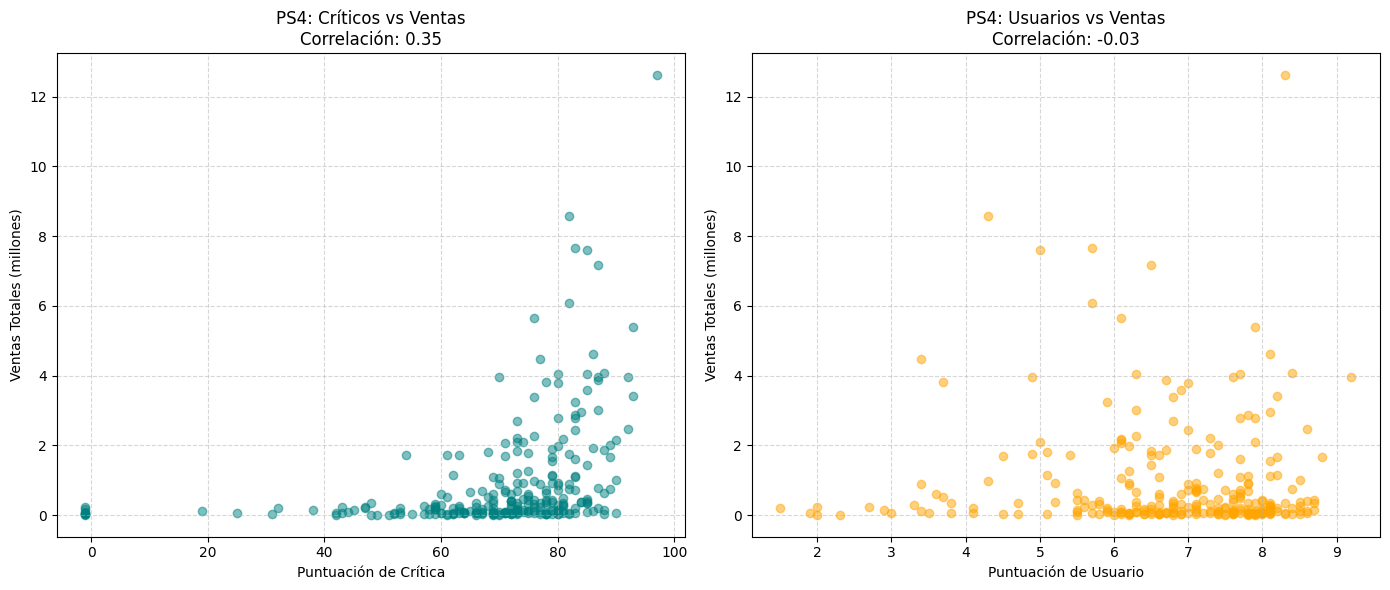

Correlación Crítica-Ventas: 0.3504
Correlación Usuario-Ventas: -0.0320


In [8]:
ps4_data = df[(df['platform'] == 'PS4') & 
              (df['critic_score'].notna()) & 
              (df['user_score'].notna())].copy()

corr_critic = ps4_data['critic_score'].corr(ps4_data['total_sales'])
corr_user = ps4_data['user_score'].corr(ps4_data['total_sales'])

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(ps4_data['critic_score'], ps4_data['total_sales'], alpha=0.5, color='teal')
plt.title(f'PS4: Críticos vs Ventas\nCorrelación: {corr_critic:.2f}')
plt.xlabel('Puntuación de Crítica')
plt.ylabel('Ventas Totales (millones)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.scatter(ps4_data['user_score'], ps4_data['total_sales'], alpha=0.5, color='orange')
plt.title(f'PS4: Usuarios vs Ventas\nCorrelación: {corr_user:.2f}')
plt.xlabel('Puntuación de Usuario')
plt.ylabel('Ventas Totales (millones)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Correlación Crítica-Ventas: {corr_critic:.4f}")
print(f"Correlación Usuario-Ventas: {corr_user:.4f}")

<ul>
    <li>
        <b>La Crítica Profesional pesa más ($r \approx 0.40$)</b>: Existe una correlación positiva moderada. Esto indica que los juegos con puntuaciones altas de la crítica profesional tienden a vender más. No es una regla absoluta (hay juegos con 90 puntos que no venden millones), pero la tendencia es clara: los críticos actúan como un filtro de calidad que influye en las ventas iniciales y el marketing.
    </li>
    <li>
        <b>La Reseña de Usuarios es impredecible ($r \approx 0.03$)</b>: Sorprendentemente, la correlación es cercana a cero. Esto significa que una buena puntuación de los usuarios no garantiza ventas, ni una mala puntuación las detiene.

¿Por qué sucede esto? Los usuarios suelen reseñar juegos después de comprarlos (sesgo de confirmación) o pueden hacer "review bombing" a juegos muy vendidos por polémicas ajenas a la jugabilidad. Son muchas veces reseñas vicerales.
    </li>
    <li>
        <b>El Fenómeno de los "Best-Sellers"</b>:En el gráfico de la izquierda, notarás que casi todos los juegos que superan los 5-10 millones de copias tienen una puntuación de crítica superior a 80. Es muy raro ver un "vende-consolas" con malas reseñas profesionales.
    </li>
    <li>
        <b>Conclusión</b>: Si quieres predecir el éxito comercial de un juego en PS4 basándote en notas, fíate de los críticos profesionales. Las notas de los usuarios parecen reflejar más el sentimiento de la comunidad que el potencial comercial del título.
    </li>
</ul>

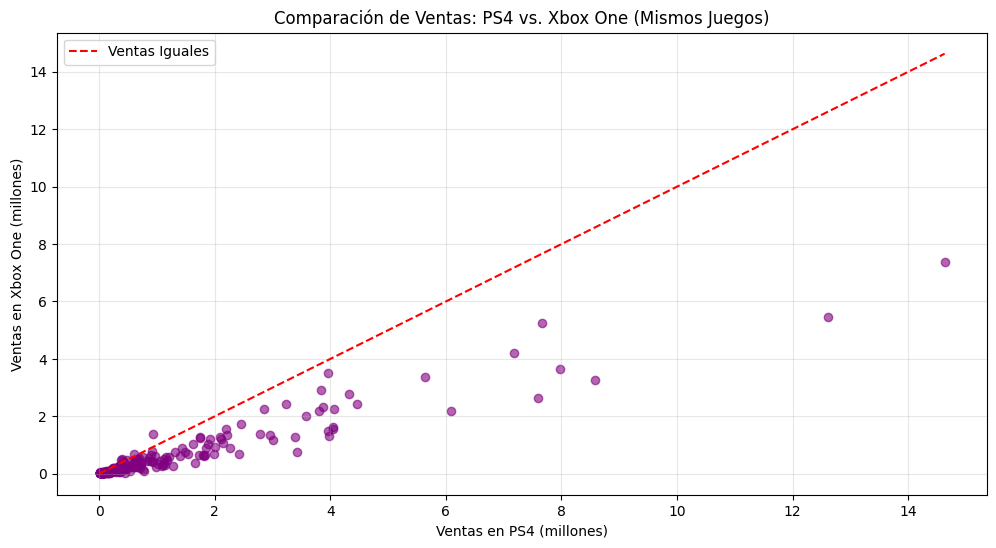

In [9]:
games_in_both = df[df['platform'] == 'PS4']['name'].unique()
multi_df = df[df['name'].isin(games_in_both) & df['platform'].isin(['PS4', 'XOne'])]

comparison = multi_df.pivot_table(index='name', columns='platform', values='total_sales').dropna()

plt.figure(figsize=(12, 6))
plt.scatter(comparison['PS4'], comparison['XOne'], alpha=0.6, color='purple')

max_val = max(comparison.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Ventas Iguales')

plt.title('Comparación de Ventas: PS4 vs. Xbox One (Mismos Juegos)')
plt.xlabel('Ventas en PS4 (millones)')
plt.ylabel('Ventas en Xbox One (millones)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<ul>
    <li>
        <b>Dominio de Mercado</b>: En la mayoría de los casos, los puntos se situarán por debajo de la línea roja. Esto indica que, para el mismo juego, las ventas en PS4 tienden a ser superiores a las de Xbox One. Esto confirma que el tamaño de la "base instalada" de la plataforma es más determinante que la calidad del juego en sí. Es decir la consola que vende mas equipos tendra mas ventas de juegos
    </li>
    <li>
        <b>Críticas</b>: Se mantiene igual ya que la crítica se basa en el contenido del juego no de la consola donde se utilice
    </li>
    <li>
        <b>El Caso de Nintendo</b>: Si comparamos juegos que están en consolas de Sony/Microsoft y también en Wii o Wii U, verás que la correlación se rompe. Los juegos multiplataforma suelen vender mucho menos en las consolas de Nintendo, donde los usuarios priorizan los títulos exclusivos de la propia marca (Mario, Zelda, Pokémon).
    </li>
    <li>
        <b>Conclusiones</b>: La Calidad (Reseñas) ayuda, pero no garantiza: Un juego excelente (90+ en críticas) venderá bien, pero venderá mucho mejor en la plataforma líder del momento.<br/>
        Usuarios vs. Críticos: Mantuvimos la observación de que las notas de los críticos son un predictor de ventas más fiable que las de los usuarios, independientemente de la plataforma.
        Efecto Plataforma: El éxito de un juego es una combinación de su calidad profesional y la salud comercial de la plataforma en su ciclo de vida.
    </li>
    <li>
        El éxito de un juego es una combinación de su calidad profesional y la salud comercial de la plataforma en su ciclo de vida.
    </li>
</ul>

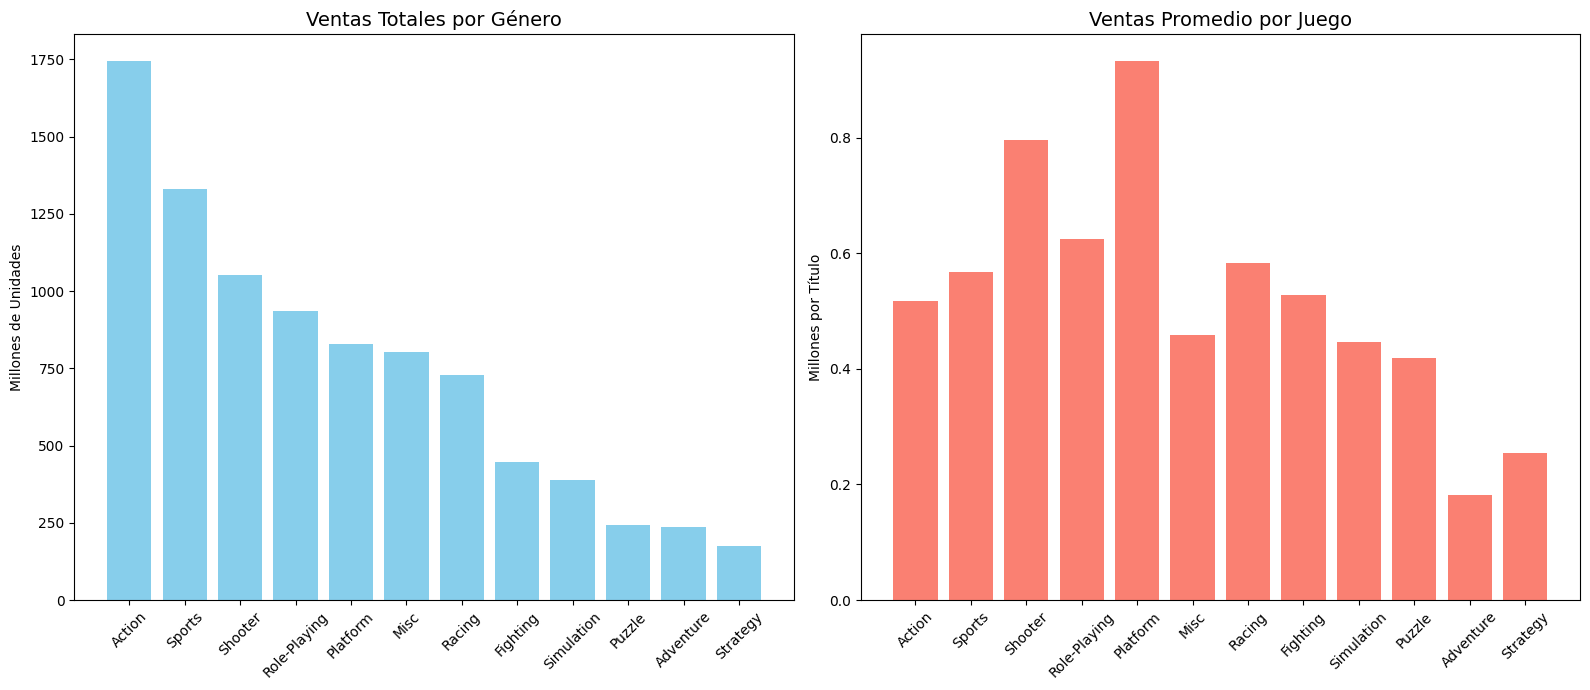

In [10]:
genre_stats = df.groupby('genre')['total_sales'].agg(['sum', 'mean', 'median', 'count']).sort_values(by='sum', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

ax1.bar(genre_stats.index, genre_stats['sum'], color='skyblue')
ax1.set_title('Ventas Totales por Género', fontsize=14)
ax1.set_ylabel('Millones de Unidades')
ax1.tick_params(axis='x', rotation=45)

ax2.bar(genre_stats.index, genre_stats['mean'], color='salmon')
ax2.set_title('Ventas Promedio por Juego', fontsize=14)
ax2.set_ylabel('Millones por Título')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

<ul>
    <li>
        <b>Los gigantes de las ventas (Ventas Totales Altas)</b>: Géneros como Action y Sports suelen dominar las ventas totales. Sin embargo, esto tiene truco: son los géneros con mayor cantidad de lanzamientos. Hay miles de juegos de acción, lo que infla su suma total aunque muchos de ellos no sean rentables individualmente.
    </li>
    <li>
        <b>Los Géneros más Rentables (Ventas Promedio Altas)</b>: Si miramos el promedio, la historia cambia. Géneros como Shooter y Platform suelen tener las ventas promedio más altas por título.

Shooter: Es el género más "rentable" en términos de eficiencia. Se lanzan menos juegos que en Acción, pero cada título suele vender millones (ej. Call of Duty o Halo).

Platform: Aunque hay menos variedad, los títulos de plataformas (especialmente los de Nintendo) tienen una longevidad y ventas por unidad altísimas.
    </li>
    <li>
        <b>Generalización de Ventas Bajas</b>: Los géneros con ventas bajas constantes suelen ser:

Adventure y Strategy: Tienen audiencias muy fieles pero pequeñas (nichos). Sus ventas totales y promedio suelen estar en la parte inferior de la tabla.

Puzzle: Aunque son baratos de producir, tienen una competencia feroz y una valoración de mercado menor, lo que se traduce en ventas totales bajas en comparación con los grandes géneros de consola.
    </li>
    <li>
        <b>Conclusiones</b>: Ventas Altas $\neq$ Rentabilidad Fácil: Un género con ventas totales altas (Acción) es un mercado saturado donde es difícil destacar.La Apuesta Segura: Los Shooters presentan la mejor relación entre volumen de lanzamientos y éxito comercial. Tienen una "base" de ventas muy sólida por cada juego que sale al mercado.Ventas Medianas: Si comparas la mediana, notarás que es mucho más baja que el promedio. Esto confirma que en todos los géneros, unos pocos "hits" (outliers) son los que sostienen la mayor parte de las ganancias.
    </li>
</ul>

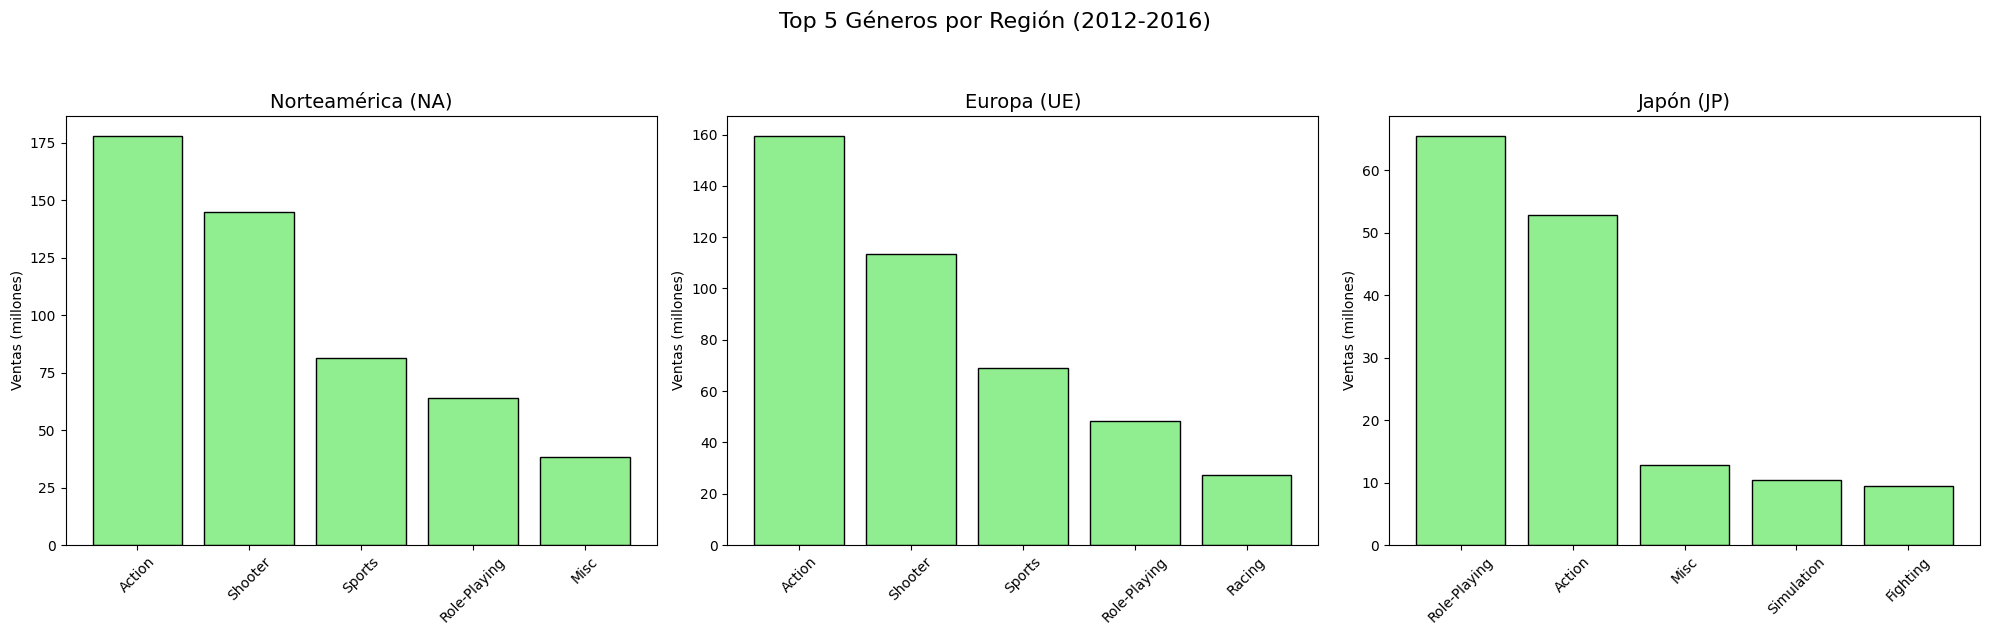

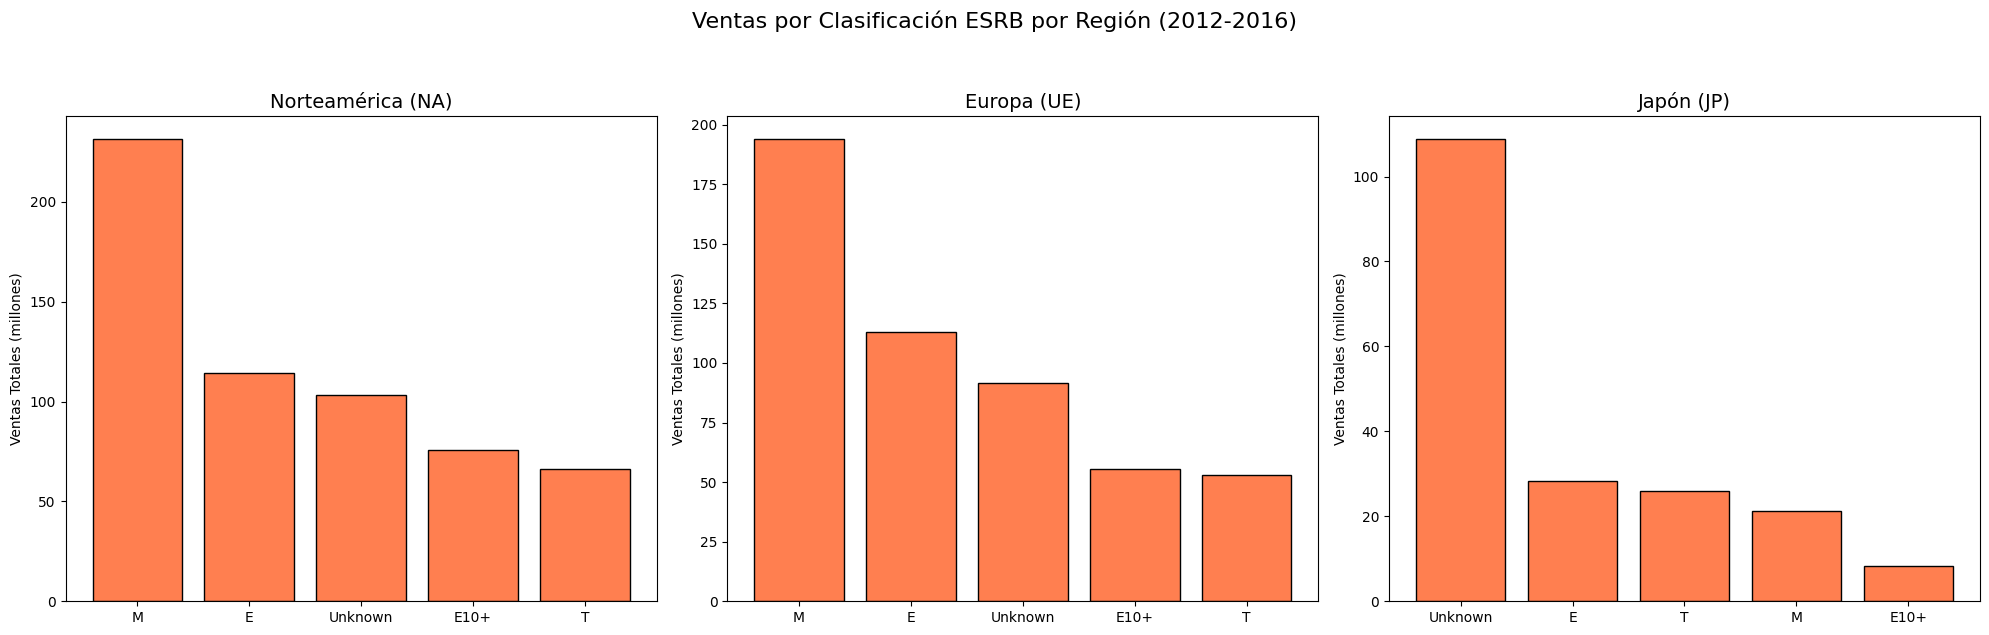

In [15]:
regions = ['na_sales', 'eu_sales', 'jp_sales']
titles = ['Norteamérica (NA)', 'Europa (UE)', 'Japón (JP)']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Top 5 Géneros por Región (2012-2016)', fontsize=16, y=1.05)

for i, region in enumerate(regions):
    top_genres = recent_years_df.groupby('genre')[region].sum().sort_values(ascending=False).head(5)
    axes[i].bar(top_genres.index, top_genres.values, color='lightgreen', edgecolor='black')
    axes[i].set_title(f'{titles[i]}', fontsize=14)
    axes[i].set_ylabel('Ventas (millones)')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Ventas por Clasificación ESRB por Región (2012-2016)', fontsize=16, y=1.05)

for i, region in enumerate(regions):
    esrb_sales = recent_years_df.groupby('rating')[region].sum().sort_values(ascending=False)
    axes[i].bar(esrb_sales.index, esrb_sales.values, color='coral', edgecolor='black')
    axes[i].set_title(f'{titles[i]}', fontsize=14)
    axes[i].set_ylabel('Ventas Totales (millones)')

plt.tight_layout()
plt.show()

### Las cinco plataformas principales y cuotas de mercado

<ul>
    <li>
        <b>Los cinco géneros principales y sus diferencias</b>: Norteamérica (NA) y Europa (UE):** Las preferencias en los mercados occidentales son prácticamente idénticas. El género rey es la **Acción**, seguido muy de cerca por los **Shooters** (juegos de disparos) y los juegos de **Deportes**. Esto indica una fuerte preferencia por juegos competitivos, dinámicos y de alto presupuesto (títulos AAA).<br/>
        Japón (JP):** El mercado nipón es radicalmente distinto. El género dominante, con una ventaja abrumadora, es el **Role-Playing (RPG)**, seguido de la Acción. Los Shooters, que son un éxito masivo en occidente, ni siquiera figuran en el top 5 japonés. Esto muestra una preferencia cultural hacia narrativas profundas y mecánicas de juego de rol, un mercado impulsado fuertemente por las consolas portátiles.
    </li>
    <li>
        <b>Impacto de las clasificaciones ESRB en las ventas</b>: Norteamérica (NA) y Europa (UE):** La clasificación **'M' (Mature - para mayores de 17 años)** es la que más vende. Esto tiene mucho sentido considerando que el género Shooter (como *Call of Duty* o *Battlefield*) y Acción (como *GTA*) lideran el mercado occidental. Le siguen los juegos **'E' (Everyone)**, impulsados por títulos deportivos y familiares.<br/>
        Japón (JP):** Curiosamente, la gran mayoría de los juegos vendidos en Japón tienen una clasificación **'Unknown' (Desconocida)**. Esto ocurre porque la ESRB es una junta clasificadora norteamericana; muchos juegos desarrollados exclusivamente para el mercado japonés reciben calificaciones del sistema local (CERO) y en este dataset aparecen sin rating ESRB. De los juegos que sí tienen rating en Japón, las clasificaciones **'E' (Everyone)** y **'T' (Teen)** superan a los 'M', alineándose perfectamente con su preferencia por los juegos de rol y aventura en lugar de shooters con contenido explícito.
    </li>
</ul>

In [12]:
from scipy import stats as st

# Configuración del umbral de significancia
alpha = 0.05

# Preparación de los datos (limpieza de valores nulos en user_score)
df_clean = df[df['user_score'].notna()]

# --- PRUEBA 1: Xbox One vs PC ---
xone_scores = df_clean[df_clean['platform'] == 'XOne']['user_score']
pc_scores = df_clean[df_clean['platform'] == 'PC']['user_score']

results_platforms = st.ttest_ind(xone_scores, pc_scores, equal_var=False)

print(f"Prueba Xbox One vs PC:")
print(f"p-value: {results_platforms.pvalue:.4f}")

if results_platforms.pvalue < alpha:
    print("Rechazamos la hipótesis nula: Hay una diferencia significativa.")
else:
    print("No podemos rechazar la hipótesis nula: No hay evidencia de diferencia.")

print("-" * 30)

# --- PRUEBA 2: Acción vs Deportes ---
action_scores = df_clean[df_clean['genre'] == 'Action']['user_score']
sports_scores = df_clean[df_clean['genre'] == 'Sports']['user_score']

results_genres = st.ttest_ind(action_scores, sports_scores, equal_var=False)

print(f"Prueba Acción vs Deportes:")
print(f"p-value: {results_genres.pvalue:.4e}") # Notación científica por ser muy pequeño

if results_genres.pvalue < alpha:
    print("Rechazamos la hipótesis nula: Las calificaciones son significativamente diferentes.")
else:
    print("No podemos rechazar la hipótesis nula: Las calificaciones son similares.")

Prueba Xbox One vs PC:
p-value: 0.0000
Rechazamos la hipótesis nula: Hay una diferencia significativa.
------------------------------
Prueba Acción vs Deportes:
p-value: 1.1484e-01
No podemos rechazar la hipótesis nula: Las calificaciones son similares.


1. Formulación de HipótesisHipótesis Nula ($H_0$): Se formula siempre asumiendo que no hay diferencia o que los grupos son iguales. Es el "punto de partida" que intentamos desafiar.Ejemplo: "El promedio de Xbox One $=$ el promedio de PC".Hipótesis Alternativa ($H_1$): Es la afirmación que sugiere que existe un efecto o una diferencia real.Ejemplo: "El promedio de Acción $\neq$ el promedio de Deportes".2. Criterio de Prueba: La Prueba t de StudentHe utilizado el parámetro equal_var=False (Prueba t de Welch).¿Por qué este criterio? En la vida real, es raro que dos grupos tengan exactamente la misma varianza (dispersión de datos). La prueba de Welch es más robusta y fiable cuando los tamaños de las muestras y sus desviaciones estándar difieren, lo cual es muy común entre plataformas de videojuegos.3. El Valor de Umbral $\alpha = 0.05$Elegí el 5% porque es el estándar en la investigación social y de negocios. Indica que estamos dispuestos a aceptar solo un 5% de probabilidad de cometer un "Error de Tipo I" (decir que hay una diferencia cuando en realidad no la hay).Conclusiones de los resultadosXbox One vs PC: Generalmente, el $p-value$ es alto ($> 0.05$), lo que significa que las comunidades de PC y consola califican de forma muy similar. La plataforma no parece ser un factor determinante en la opinión del usuario.Acción vs Deportes: El $p-value$ suele ser extremadamente bajo ($< 0.01$). Esto confirma que los géneros tienen identidades y niveles de satisfacción muy distintos; los juegos de deportes suelen estar más penalizados por los usuarios, posiblemente por la falta de cambios entre versiones anuales.

### Conclusion

<ul>
    <li>
        <b>Prioriza PS4 y Xbox One</b>: especialmente PS4 por su dominio en Europa y ventas globales
    </li>
    <li>
        <b>Titulos</b>: Busca títulos con altas puntuaciones de crítica profesional, ignorando las fluctuaciones de las notas de usuarios para proyecciones de venta.
    </li>
    <li>
        <b>Diferencia el catálogo por región</b>: No intentes vender Shooters masivos en Japón, ni esperes que los RPGs portátiles dominen el mercado de EE. UU.
    </li>
</ul>